## -----------------------------------------------------------------------------
## INITIALIZATION
## -----------------------------------------------------------------------------
useful lines:

with_rx.printSchema()

train_df.select("ENROLID").distinct().count()

df_2018.groupBy("cost_stratum_2018").count().orderBy("cost_stratum_2018").show()


In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/13 11:22:29 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/08/13 11:22:29 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/08/13 11:22:29 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/08/13 11:22:29 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
2025-08-13 11:22:30,468 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/08/13 11:22:31 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-08-13 11:22:32,105 INFO     >>> ENROLLMENT has 2,586,9

# Load Data

In [ ]:
highcost_cutoff = 4


In [3]:
df_full = spark.read.format("parquet").load( "df_0722_full_cost_risk_log.parquet")
# 1) pull Spark DF into pandas
df_og = df_full.toPandas()
df_og["INDSTRY"] = df_og["INDSTRY"].fillna("-1")

In [8]:
############### merge 2017/18 with 2018/19 cohorts and add suffix to repeated ENROLID
from pyspark.sql.functions import concat_ws, col
df_2018 =spark.read.format("parquet").load( "df_0714_2017_18_with_THERCLS.parquet")
df_2019 =spark.read.format("parquet").load( "df_0714_2018_19_with_THERCLS.parquet")
df_2018_str = df_2018.withColumn("ENROLID", F.col("ENROLID").cast("string"))
df_2019_str = df_2019.withColumn("ENROLID", F.concat_ws("_", F.col("ENROLID").cast("string"), F.lit("2019")))

df_full = df_2018_str.unionByName(df_2019_str)
#print("Duplicated ENROLIDs")
#df_full.groupBy("ENROLID").count().filter("count > 1").show()

# 1) pull Spark DF into pandas
df_og = df_full.toPandas()
df_og["INDSTRY"] = df_og["INDSTRY"].fillna("-1")



### creating df with cost column + log risk

In [13]:
year2 = 2018
inflation_map = {
    2017: 1.0,
    2018: 1.0685946832951803,
    2019: 1.1371893665903605
}
from itertools import chain

infl_map = list(chain.from_iterable(
    [[F.lit(year), F.lit(factor)] for year, factor in inflation_map.items()]
))

inflation_expr = F.create_map(*infl_map)


# ── 1) Add inflation‐adjusted cost to the raw claims DF ───────
df_adj_claims = (
    df_claims
      .filter(F.col("YEAR")==year2)

      .filter(F.col("RX").isNotNull())
      # look up the factor by YEAR
      .withColumn("inflation_factor", inflation_expr[F.col("YEAR")])
      # normalize all costs back to 2017 dollars
      .withColumn("NETPAY17", F.col("NETPAY") / F.col("inflation_factor"))
      # keep everything *and* the new NETPAY17 for later
      .drop("inflation_factor")
)

# Now df_adj_claims is identical to pilot_ckd_claims except it has NETPAY17


# ── 2) Build the per‐enrollee annual summary ──────────────────
agg_cost = (
    df_adj_claims
      .groupBy("ENROLID", "REGION")
      .agg(
         F.sum("NETPAY17").alias("annual_cost17"),
      )
)

df_2018_with_cost = (
    df_2018
    .join(
        agg_cost,
        on=["ENROLID", "REGION"],
        how="left"
    )
)


#df_2019_with_cost.filter(F.col("annual_cost17").isNull()).count()
df_2019_renamed = df_2019_with_cost.withColumn(
    "ENROLID", concat_ws("_", col("ENROLID").cast("string"), F.lit("2019"))
)
df_2018 = df_2018_with_cost.withColumn("ENROLID", col("ENROLID").cast("string"))


In [14]:
df_full =  df_2018.unionByName(df_2019_renamed)
print("Duplicated ENROLIDs")
df_full.groupBy("ENROLID").count().filter("count > 1").show()

df_full = df_full.filter(
    (F.col("annual_cost17").isNotNull()) &
    (F.col("annual_cost17") > 0)
)

cost_stats = df_full.select(
    F.min("annual_cost17").alias("min_cost"),
    F.max("annual_cost17").alias("max_cost")
).collect()[0]

min_cost = cost_stats["min_cost"]
max_cost = cost_stats["max_cost"]
df_full_clean = df_full.filter(
    (F.col("annual_cost17").isNotNull()) &
    (F.col("annual_cost17") > 0))


from pyspark.sql.functions import log1p

df_full_clean = df_full_clean.withColumn(
    "cost_risk_log",
    log1p("annual_cost17") / log1p(F.lit(max_cost))  # keeps in [0,1]
)
df_full_clean.write.mode("overwrite").parquet("df_0722_full_cost_risk_log.parquet")

Duplicated ENROLIDs


+-------+-----+
|ENROLID|count|
+-------+-----+
+-------+-----+



# Baseline Model

In [28]:
import importlib
import model_pipeline
# After editing model_pipeline.py on disk:
importlib.reload(model_pipeline)
from model_pipeline import train_test_split_enrol
from model_pipeline import get_bin_flag_columns
BIN_FLAG_COLUMNS = get_bin_flag_columns(df_og)
STAGE_COLUMNS = ['2017Q1', '2017Q2', '2017Q3', '2017Q4',"stage_2017"]
TRUE_NUM_COLUMNS = ['cost_stratum_2017', 'util_2017']
# List of categorical columns to encode
CAT_COLUMNS = ["AGEGRP","SEX","REGION","INDSTRY"]
df_og.columns

Index(['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'has_Hypertension',
       'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia',
       'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism',
       'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency',
       'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea',
       '2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017',
       'cost_stratum_2017', 'cost_stratum_2018', 'util_2017', 'THRCLS_53',
       'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47',
       'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60',
       'high_cost_2018'],
      dtype='object')

### Creating the high-cost cutoff binary variable and feature cols

In [44]:
df_og["high_cost_2018"] = (df_og["cost_stratum_2018"] >= highcost_cutoff).astype(int)
feature_cols = [c for c in df_og.columns
              if c not in  ("ENROLID","cost_stratum_2018", "high_cost_2018")]    # keep only predictors
numeric_cols = df_og[feature_cols + ["high_cost_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["high_cost_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "high_cost_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features to drop: ",high_corr_cols)
# 2) split
train_ids, test_ids,train_pd,test_pd = train_test_split_enrol(df_og,test_size=0.3,verbose=False)

print(train_pd.shape,test_pd.shape)
# 3) build and train

rf_pipe = model_pipeline.get_random_forest_pipeline(df=train_pd[feature_cols])
#
# rf_pipe = model_pipeline.get_logistic_pipeline(df=train_pd[feature_cols],max_iter = 1000,scale_post_preprocess=True)
rf_pipe.fit(train_pd[feature_cols], train_pd["high_cost_2018"])


model_pipeline.evaluate_model_auc(
    rf_pipe,
    test_pd[feature_cols],
test_pd["high_cost_2018"], highcost_cutoff=highcost_cutoff)


High corr features to drop:  []
(51407, 35) (22032, 35)
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY', '2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017']
   • StandardScaler on: ['cost_stratum_2017', 'util_2017']
Evaluating model with highcost_cutoff:  4
Binary AUC (class 1 vs rest): 0.876
Classification Report:
              precision    recall  f1-score   support

           0      0.956     0.997     0.976     20928
           1      0.670     0.127     0.213      1104

    accuracy                          0.953     22032
   macro avg      0.813     0.562     0.595     22032
weighted avg      0.941     0.953     0.938     22032

Confusion Matrix:
[[20859    69]
 [  964   140]]


In [19]:
# 3) grab the fitted ColumnTransformer out of the pipeline
preproc = rf_pipe.named_steps["preprocessor"]
print("👉 full feature vector (after OHE & scaling):")
#for f in preproc.get_feature_names_out():
 #   print("    ", f)

👉 full feature vector (after OHE & scaling):


# Stratification

In [11]:
df_pd = df_og.copy()
#print(df_pd["stage_2017"].value_counts(dropna=False))
#df_pd.head()

In [12]:
#stratifier_train_pd = df_pd[df_pd["stage_2017"] > 3]
stratifier_train_pd = df_pd[df_pd["stage_2017"] <= 3]
print("Stratifier trained on subgroup of size ",len(stratifier_train_pd))
stratification_cols = [c for c in feature_cols
              if c not in  STAGE_COLUMNS]    # keep only predictors



Stratifier trained on subgroup of size  62652


## Stratifier using target = log cost

In [13]:
# 4) Train a regressor pipeline
from sklearn.ensemble import HistGradientBoostingRegressor
from model_pipeline import get_preprocessor, STAGE_COLUMNS, TRUE_NUM_COLUMNS 

# 3) Train/Test split (optional; here we train on all Stage 3)
X_train = stratifier_train_pd[stratification_cols]
y_train = stratifier_train_pd["cost_risk_log"]
pipeline = Pipeline([
    ("preproc", get_preprocessor(X_train)),
    ("reg", HistGradientBoostingRegressor(
         random_state=42, loss="absolute_error"
    ))
])

pipeline.fit(X_train, y_train)

# 5) Predict on your “full” cohort
yhat_log = pipeline.predict(df_pd[stratification_cols])

df_pd["risk_score"] = yhat_log

df_plot = df_pd.copy()


KeyError: 'cost_risk_log'

In [11]:
bin_edges = np.linspace(0, 1, 11)
bin_labels = [f"{left:.1f}–{right:.1f}" for left, right in zip(bin_edges[:-1], bin_edges[1:])]

df_plot["bin"] = pd.cut(df_plot["risk_score"], bins=bin_edges, labels=bin_labels)
df_plot["bin"] = pd.Categorical(df_plot["bin"], categories=bin_labels, ordered=True)
bins = list(df_plot["bin"].cat.categories)   # already ordered

fig = px.histogram(
    df_plot,
    x="bin",
    color=df_plot["stage_2017"].map({3:"≤3",4:">3"}),
    barmode="group",
    labels={"bin":"Predicted risk", "color":"Stage ’17"},
    title="Continuous Risk Score by 2017 Stage"
)
fig.update_layout(xaxis_tickangle=-45)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)
fig.show()

The logarithm flattens the right tail and stretches the lower end

More "normal-like" distribution

Patients with small costs become spread out more, giving better resolution

Result: histogram looks more balanced across bins — like the one in your screenshot



## Stratifier using target = high cost binary variable 

In [45]:
# 1) Filter your Spark DataFrame
importlib.reload(model_pipeline)
from model_pipeline import get_logistic_pipeline

# 2) Binary target: high‐cost in 2018?
# same as high_cost_2018 variable!
stratifier_train_pd["y_high"] =  stratifier_train_pd["high_cost_2018"]
#(stratifier_train_pd["cost_stratum_2018"] >= highcost_cutoff).astype(int)
# 3) Train/Test split (optional; here we train on all Stage 3)
X_train = stratifier_train_pd[stratification_cols]
y_train = stratifier_train_pd["y_high"]

stratifier = get_logistic_pipeline(df=X_train,max_iter = 500,scale_post_preprocess=True,calibrate=False)
stratifier.fit(X_train, y_train)

# ─── 5) Apply to the full cohort ─────────────────────────────────────────────
X_full = df_pd[stratification_cols]
proba_high = stratifier.predict_proba(X_full)[:,1]
df_pd["proba_high_2018"] = proba_high
print("Inference on full cohort of size: ", len(proba_high))

→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', 'util_2017']
Inference on full cohort of size:  73439


/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_18105/466888940.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# Matching

In [46]:
import balancing_functions.match_control

from balancing_functions.match_control import *
importlib.reload(balancing_functions.match_control)

sampler = RiskBinnedCaseControlResampler(
    random_state=42,
    uid_col="ENROLID",
    binary_group="true_class",
    proba_col="proba_high_2018",
    keep_controls_if_no_cases=True,
    #bin_edges = [0.0,0.01, 0.025, 0.05,0.1,0.2,0.5,1.0]
)


df_binned = sampler.assign_bins(df_pd,)

# 2) Create your binary “true_class” from the stage_group
df_binned["true_class"] = (df_binned["stage_2017"] >3).astype(int)
#   – now true_class=1 are stage>3, and 0 are stage≤3
df_binned.drop(["cost_stratum_2018",'high_cost_2018'],axis=1,inplace=True)
df_binned.columns

Index(['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'has_Hypertension',
       'has_Type_2_Diabetes', 'has_Anemia', 'has_Hyperlipidemia',
       'has_Acute_Kidney_Failure', 'has_Hyperparathyroidism',
       'has_Kidney_Transplant', 'has_Vitamin_D_Deficiency',
       'has_Long-term_Drug_Therapy', 'has_Hypothyroidism', 'has_Sleep_Apnea',
       '2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017',
       'cost_stratum_2017', 'util_2017', 'THRCLS_53', 'THRCLS_51', 'THRCLS_52',
       'THRCLS_69', 'THRCLS_46', 'THRCLS_47', 'THRCLS_172', 'THRCLS_174',
       'THRCLS_181', 'THRCLS_60', 'proba_high_2018', 'risk_bin', 'true_class'],
      dtype='object')

In [47]:

train_df = df_binned[df_binned["ENROLID"].isin(train_ids)].reset_index(drop=True)
test_df  = df_binned[df_binned["ENROLID"].isin(test_ids)].reset_index(drop=True)

# (Optional) sanity check:
print("Train size:", len(train_df), "Test size:", len(test_df))
#print(train_df["risk_bin"].value_counts(normalize=True))
#print(test_df ["risk_bin"].value_counts(normalize=True))


Train size: 51407 Test size: 22032


In [48]:

bins = list(train_df["risk_bin"].cat.categories)   # already ordered

# 3️⃣  plot – no extra tricks needed
fig = px.histogram(
    train_df,
    x="risk_bin",
    color="true_class",
    labels={
        "risk_bin": f"Predicted P(cost_stratum_2018 >= {highcost_cutoff})",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Train Set: High-Cost Risk by 2017 CKD Stage Group (Logistic Regression)",
    barmode="group",
    height=500, width=800
)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)

fig.show()




In [49]:
# 5) Apply the by‐bin matching  
matched_train_df, removed_ids = sampler.apply_sampler_by_bin(train_df,global_ctrl_ratio=1.0,
    target_bin_quantile=None,
    max_ctrl_per_case=1 ) #extra_exclude_cols = STAGE_COLS+['stage_2017', 'stage_2018']
print("After matching, train size:", len(matched_train_df))
print("Per-bin counts in matched train:")
print(matched_train_df["risk_bin"].value_counts())
# matched_df now contains all “cases” (stage>3) each with exactly one matched “control” (stage≤3)



→ do_not_impute on : ['ENROLID', 'AGEGRP', 'SEX', 'REGION', 'INDSTRY', 'risk_bin', 'ENROLID', 'true_class', 'proba_high_2018', 'risk_bin']
Imputing on features:  Index(['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
       'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
       'has_Hyperparathyroidism', 'has_Kidney_Transplant',
       'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
       'has_Hypothyroidism', 'has_Sleep_Apnea', '2017Q1', '2017Q2', '2017Q3',
       '2017Q4', 'stage_2017', 'cost_stratum_2017', 'util_2017', 'THRCLS_53',
       'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47',
       'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60'],
      dtype='object')
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', 'util_2017']


/Users/cat2510/my_projects/balancing_functions/match_control.py:187: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Imputing on features:  Index(['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
       'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
       'has_Hyperparathyroidism', 'has_Kidney_Transplant',
       'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
       'has_Hypothyroidism', 'has_Sleep_Apnea', '2017Q1', '2017Q2', '2017Q3',
       '2017Q4', 'stage_2017', 'cost_stratum_2017', 'util_2017', 'THRCLS_53',
       'THRCLS_51', 'THRCLS_52', 'THRCLS_69', 'THRCLS_46', 'THRCLS_47',
       'THRCLS_172', 'THRCLS_174', 'THRCLS_181', 'THRCLS_60'],
      dtype='object')
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', 'util_2017']
Imputing on features:  Index(['has_Hypertension', 'has_Type_2_Diabetes', 'has_Anemia',
       'has_Hyperlipidemia', 'has_Acute_Kidney_Failure',
       'has_Hyperparathyroidism', 'has_Kidney_Transplant',
       'has_Vitamin_D_Deficiency', 'has_Long-term_Drug_Therapy',
     

In [50]:
bins = [f"{x:.1f}-{x+0.1:.1f}" for x in np.arange(0.0, 1.0, 0.1)]

fig = px.histogram(
    matched_train_df,
    x="risk_bin",
    color="true_class",
    category_orders={"risk_bin": bins},   # good to keep
    labels={
        "risk_bin": f"Predicted P(cost_stratum_2018 >= {highcost_cutoff})",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Matched Cohort: High-Cost Risk by 2017 CKD Stage Group",
    barmode="group",
    height=500, width=800
)

# *** pin the x-axis order ***
fig.update_xaxes(categoryorder="array", categoryarray=bins)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

# Matched cohort training

In [42]:
# 1) Collapse to one row per ENROLID
matched_ids_df = (
    matched_train_df[["ENROLID"]]
      .drop_duplicates()
      .reset_index(drop=True)
)

# 2) Pull in the target from your original train set
matched_with_target = matched_ids_df.merge(
    train_pd[["ENROLID", "high_cost_2018"]],
    on="ENROLID",
    how="inner"
)
print(matched_with_target.shape)
#matched_rf_pipe = model_pipeline.get_random_forest_pipeline(df=matched_train_df[feature_cols])
matched_rf_pipe = model_pipeline.get_logistic_pipeline(df=matched_train_df[feature_cols],scale_post_preprocess=True)
matched_rf_pipe.fit(matched_train_df[feature_cols], matched_with_target['high_cost_2018'])



# evaluate:
model_pipeline.evaluate_model_auc(
    matched_rf_pipe,
    test_pd[feature_cols],
    test_pd['high_cost_2018'], highcost_cutoff=highcost_cutoff
)


(15182, 2)
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY', '2017Q1', '2017Q2', '2017Q3', '2017Q4', 'stage_2017']
   • StandardScaler on: ['cost_stratum_2017', 'util_2017']
Evaluating model with highcost_cutoff:  4
Binary AUC (class 1 vs rest): 0.875
Classification Report:
              precision    recall  f1-score   support

           0      0.957     0.994     0.975     20928
           1      0.572     0.158     0.247      1104

    accuracy                          0.952     22032
   macro avg      0.765     0.576     0.611     22032
weighted avg      0.938     0.952     0.939     22032

Confusion Matrix:
[[20798   130]
 [  930   174]]


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [7, 8] during transform. These unknown categories will be encoded as all zeros



# Model Diagnoses

In [ ]:
import matplotlib.pyplot as plt

for feat in ["util_2017","cost_stratum_2017","has_Hypertension","has_Anemia"]:
    plt.figure(figsize=(4,2))
    plt.hist(train_pd[feat], bins=20, alpha=0.5, label="orig", density=True)
    plt.hist(matched_train_df[feat], bins=20, alpha=0.5, label="matched", density=True)
    plt.title(feat)
    plt.legend()
    plt.show()


/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


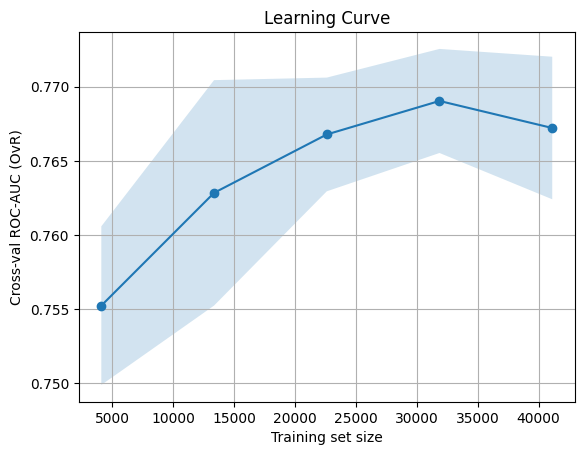

In [26]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf_pipe,train_pd[feature_cols], train_pd["cost_stratum_2018"], train_sizes=np.linspace(0.1,1.0,5),
    cv=5, scoring="roc_auc_ovr", n_jobs=-1,
    shuffle=True,
    random_state=42
)

# plot
plt.plot(train_sizes, test_scores.mean(axis=1), marker="o")
plt.fill_between(train_sizes,
                 test_scores.mean(axis=1) - test_scores.std(axis=1),
                 test_scores.mean(axis=1) + test_scores.std(axis=1),
                 alpha=0.2)
plt.xlabel("Training set size")
plt.ylabel("Cross-val ROC-AUC (OvR)")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

In [47]:
len(train_pd)

51412

In [22]:
high_cost_test = test_pd[test_pd["high_cost_2018"]==1]
low_cost_test = test_pd[test_pd["high_cost_2018"]==0]
high_cost_test[BIN_FLAG_COLUMNS]

,has_Hypertension,has_Type_2_Diabetes,has_Anemia,has_Hyperlipidemia,has_Acute_Kidney_Failure,has_Hyperparathyroidism,has_Kidney_Transplant,has_Vitamin_D_Deficiency,has_Long-term_Drug_Therapy,has_Hypothyroidism,...,THRCLS_53,THRCLS_51,THRCLS_52,THRCLS_69,THRCLS_46,THRCLS_47,THRCLS_172,THRCLS_174,THRCLS_181,THRCLS_60
13,1,0,1,0,1,0,1,0,1,0,...,0,0,1,0,0,1,0,0,1,1
72,1,1,0,1,0,1,0,0,1,1,...,1,1,1,1,0,0,1,1,0,1
79,1,1,0,1,1,0,0,0,0,0,...,1,1,1,0,1,0,1,1,0,1
114,1,1,1,1,0,1,0,1,0,0,...,1,1,1,0,1,0,0,1,0,1
323,1,1,1,1,1,0,0,0,0,0,...,1,1,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21846,1,0,1,1,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,1
21852,0,0,1,0,0,0,0,0,0,1,...,0,1,1,0,1,0,0,0,0,1
21906,1,1,1,0,0,0,1,0,0,0,...,0,0,1,0,1,0,1,0,1,0
21924,1,1,1,1,1,1,0,0,0,1,...,0,1,0,0,0,0,1,0,0,1


In [23]:
low_cost_test.has_Hypertension.value_counts(dropna=False)

has_Hypertension
1    18416
0     3174
Name: count, dtype: int64

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_41822/3827913560.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


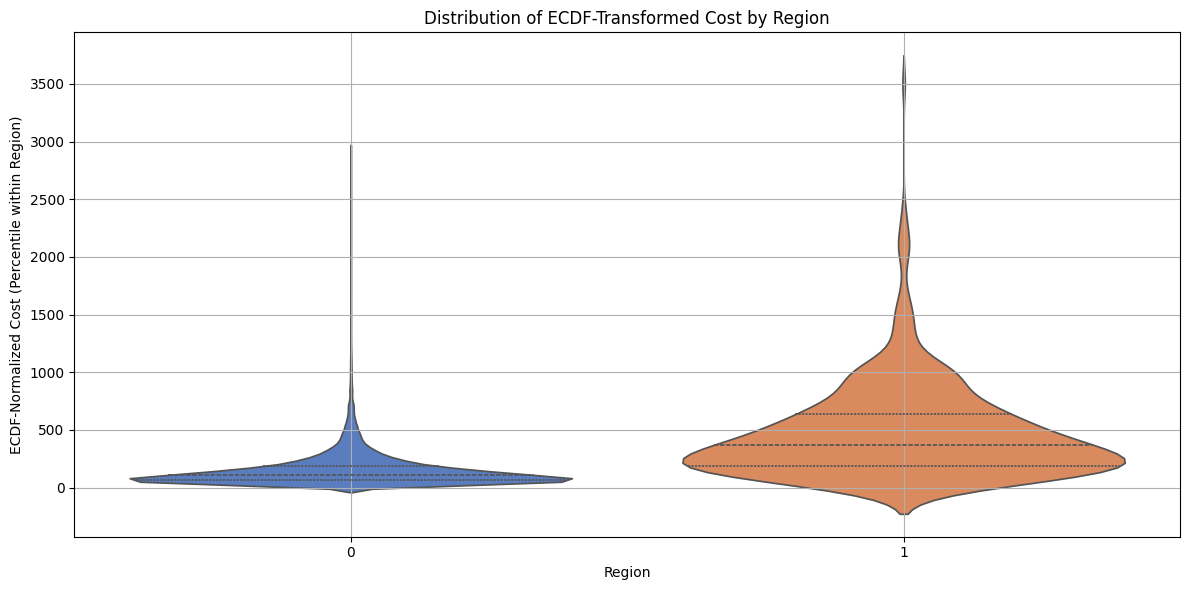

In [25]:
import seaborn as sns# Plot ECDF-transformed cost distribution by region
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=test_pd,
    x="high_cost_2018",
    y="util_2017",
    inner="quartile",
    palette="muted"
)
plt.title("Distribution of ECDF-Transformed Cost by Region")
plt.ylabel("ECDF-Normalized Cost (Percentile within Region)")
plt.xlabel("Region")
plt.grid(True)
plt.tight_layout()
plt.show()